In [3]:
import os
path=r"C:\Users\USER\Downloads\data.csv folder\data.csv"
print(os.path.exists(path))
print(os.access(path, os.R_OK))

True
True


In [3]:
import pandas as pd
df=pd.read_csv(r"C:\Users\USER\Downloads\data.csv folder\data.csv" ,encoding="latin1")

SECTION 1:LOAD AND FIRST LOOK

In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


I think the StockCode and the InvoiceNo are the most useful columns for analysis since they uniquely identify a data set and have no missing values.

A row/record is an instance in a dataset.It has columns that give information about the record.

Columns containing numbers:
1.Quantity-int64
2.UnitPrice-float64
3.CustomerID-floar64

Columns containing text:
1.InvoiceNo
2.StockCode
3.Description
4.InvoiceDate
5.Country

From our code on df.info(),we get the information on the datatypes.We have 8 columns;3 having numbers while 5 have texts.

SECTION 2:DATA CLEANING

In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

The CustomerID column has the most missing values.

In [8]:
df["CustomerID"]=df["CustomerID"].fillna("unknown")
df["Description"]=df["Description"].fillna("null")
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Decided to fill the missing CustomerID values with unknown and the Description column with null.
This is because although the data has missing values in the customerID and Description ,they can be uniquely identified using the other columns such as the InvoiceNo and the transaction had already occured.

In [9]:
df.duplicated().sum()

np.int64(5268)

In [11]:
df[df.duplicated(keep=False)].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom


In [12]:
df=df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(0)

Found 5268 duplicates in the dataset.Decided to check if the duplicates have same values through the records across all columns.Dropped duplicates and kept one of the records for each.

In [15]:
df.columns=df.columns.str.strip().str.lower().str.replace(" ","_")

In [16]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')

Confirmed if there are spaces,strip and replace with an underscore.Changed the column names to lowercase letters.

SECTION 3:EXPLORATION AND GROUPBY

In [17]:
country_orders=df.groupby("country")["invoiceno"].nunique()
#nunique() is used because one invoice number can contaain multiple products
most_orders=country_orders.idxmax()
print("Country with the most orders:",most_orders)

Country with the most orders: United Kingdom


In [18]:
country_orders=df.groupby("country")["invoiceno"].nunique()
top_orders=country_orders.max()

total_orders=df["invoiceno"].nunique()
percentage=(top_orders/total_orders)*100
print("The country with the most orders covers",percentage,"percent of the total orders")


The country with the most orders covers 90.7104247104247 percent of the total orders


In [19]:
top_products=df.groupby("description")["quantity"].sum()
top_products=top_products.sort_values(ascending=False)
top_products.head(5)

description
WORLD WAR 2 GLIDERS ASSTD DESIGNS    53751
JUMBO BAG RED RETROSPOT              47260
POPCORN HOLDER                       36322
ASSORTED COLOUR BIRD ORNAMENT        36282
PACK OF 72 RETROSPOT CAKE CASES      36016
Name: quantity, dtype: int64

Used the quantity to identitfy the best selling product since it is a more staight foward way to measure demand.

In [24]:
df["invoicedate"]=pd.to_datetime(df["invoicedate"],dayfirst=False)
df["month"]=df["invoicedate"].dt.month_name()
df["revenue"]=df["quantity"]*df["unitprice"]
monthly_sales=df.groupby("month")["revenue"].sum()
highest_sales=monthly_sales.idxmax()
lowest_sales=monthly_sales.idxmin()
print("Month with the highest total sales revenue:",highest_sales)
print("Month with the lowest total sales revenue:",lowest_sales)

Month with the highest total sales revenue: November
Month with the lowest total sales revenue: April


In [26]:
order_value=df.groupby("invoiceno")["revenue"].sum()
average_value=order_value.mean()
highest_value=order_value.max()
print("Average order value:",average_value)
print("Highest order value:",highest_value)

Average order value: 375.521504015444
Highest order value: 168469.6


In [28]:
available_negative=(df["quantity"]<0).any()#returns true if there are negative values
print(available_negative)
df[df["quantity"]<0].shape[0]

True


10587

There are products that appear to be cancelled or returned since there are negative quantity values in the dataset.

SECTION 4:VISUALISATION

Chart 1:Bar Chart

In [15]:
import pandas as pd
df=pd.read_csv(r"C:\Users\USER\Downloads\data.csv folder\data.csv" ,encoding="latin1")

df["CustomerID"]=df["CustomerID"].fillna("unknown")
df["Description"]=df["Description"].fillna("null")
df.isnull().sum()

df=df.drop_duplicates()

df.columns=df.columns.str.strip().str.lower().str.replace(" ","_")

df["invoicedate"]=pd.to_datetime(df["invoicedate"],dayfirst=False)
df["month"]=df["invoicedate"].dt.month_name()
df["revenue"]=df["quantity"]*df["unitprice"]
monthly_sales=df.groupby("month")["revenue"].sum()

country_orders=df.groupby("country")["invoiceno"].nunique()
top10_countries=country_orders.sort_values(ascending=False).head(10)
print(top10_countries)


country
United Kingdom    23494
Germany             603
France              461
EIRE                360
Belgium             119
Spain               105
Netherlands         101
Switzerland          74
Portugal             71
Australia            69
Name: invoiceno, dtype: int64


In [16]:
df.to_csv("Cleaned_ecommerce_data.csv",index=False)

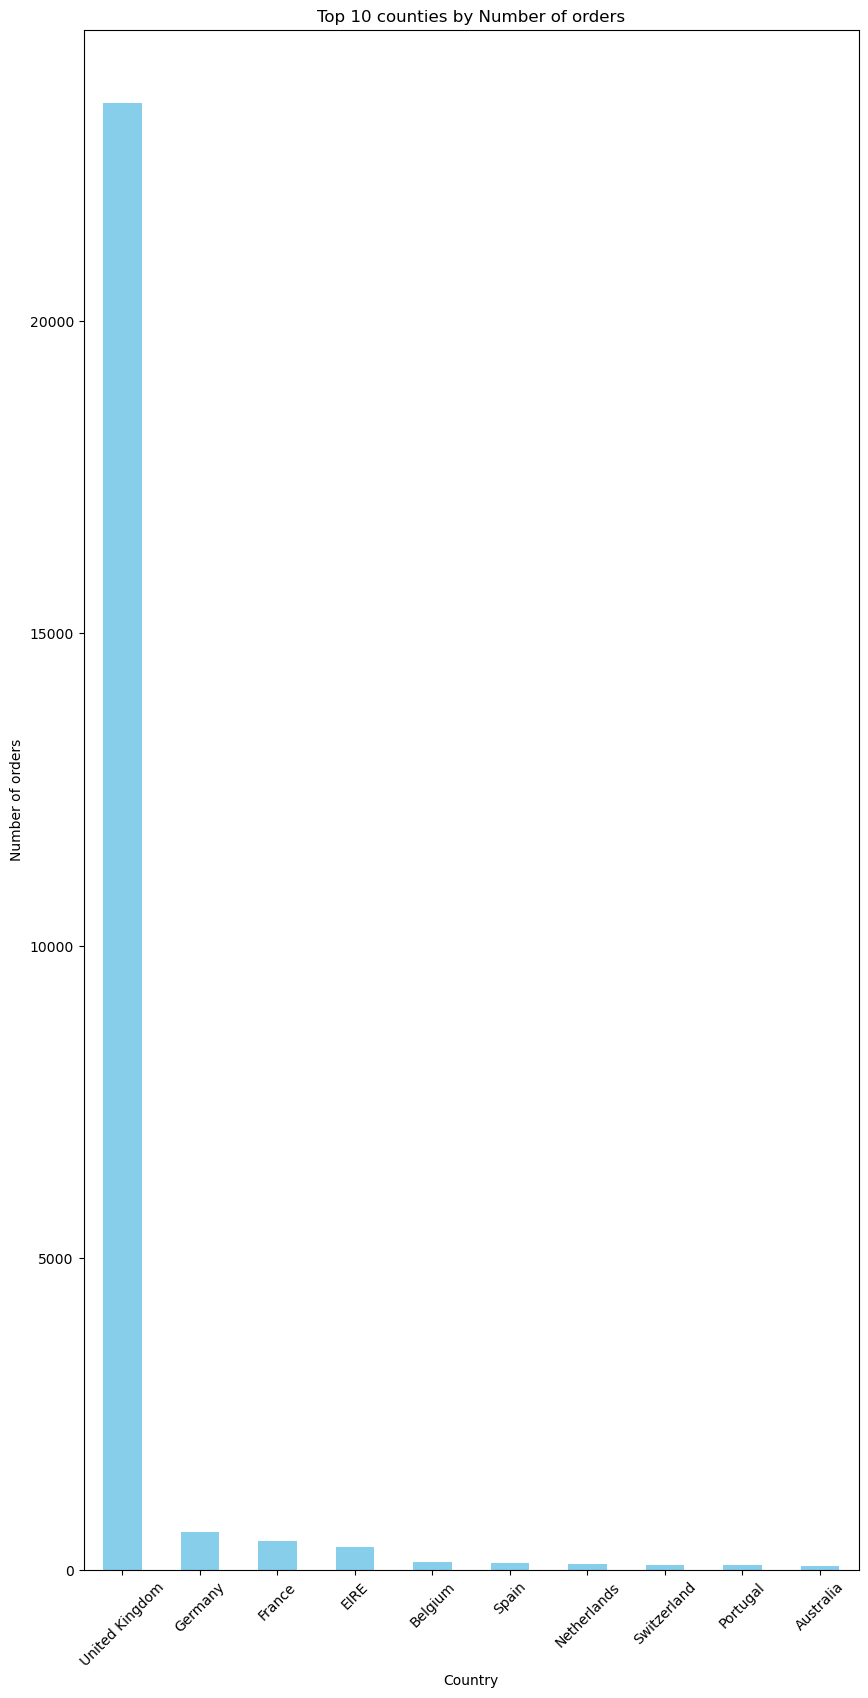

In [17]:
import pandas as pd
df=pd.read_csv("Cleaned_ecommerce_data.csv")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,20))
top10_countries.plot(kind="bar",color="skyblue")
plt.xlabel("Country")
plt.ylabel("Number of orders")
plt.title("Top 10 counties by Number of orders")
plt.xticks(rotation=45)
plt.show()

From the bar chart it shows that the business gets most of its customers from the United Kingdom.
The United Kingdom has the longest bar meaning it has the most number of orders thus the business has most of its customers located in the United Kingdom.

Chart 2:Line chart

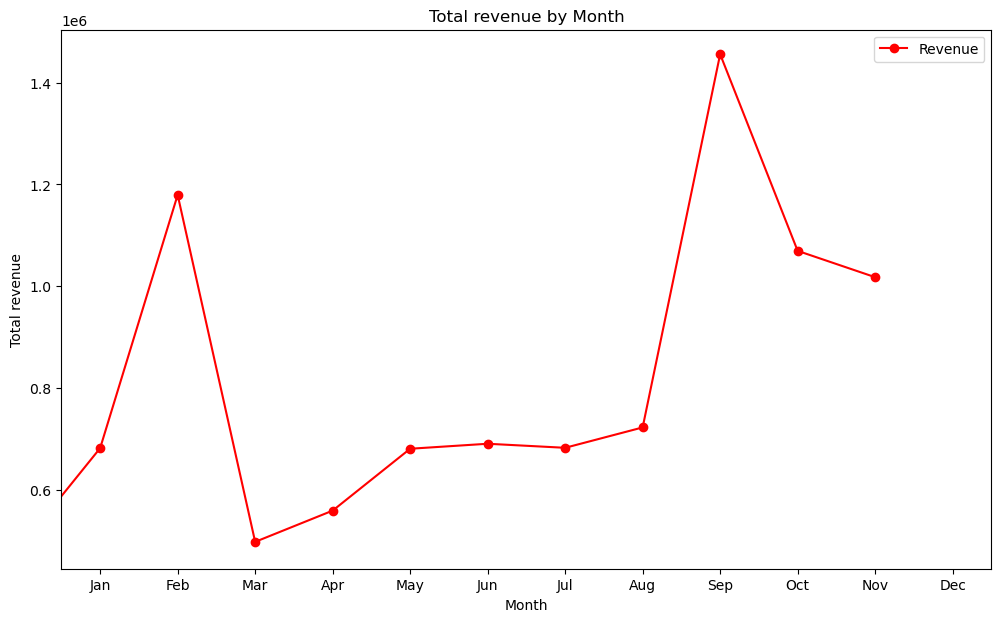

In [37]:
monthly_sales=df.groupby("month")["revenue"].sum()

plt.figure(figsize=(12,7))
plt.plot(monthly_sales.index,monthly_sales.values,color="red",marker="o",label="Revenue")
months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
plt.xticks(range(1,13),months)
plt.xlim(0.5,12.5)
plt.title("Total revenue by Month")
plt.xlabel("Month")
plt.ylabel("Total revenue")
plt.legend()
plt.show()

There is no seasonal pattern or trend in the line chart.
The business seems to be busiest during September.It is when the line chart is at its peak hence the month with the highest total revenues.

In [38]:
max_revenue=df["revenue"].max()
min_revenue=df["revenue"].min()
range=max_revenue-min_revenue
print("Range between max and min revenues:",range)#later used to determine the width of the x axis

Range between max and min revenues: 336939.2


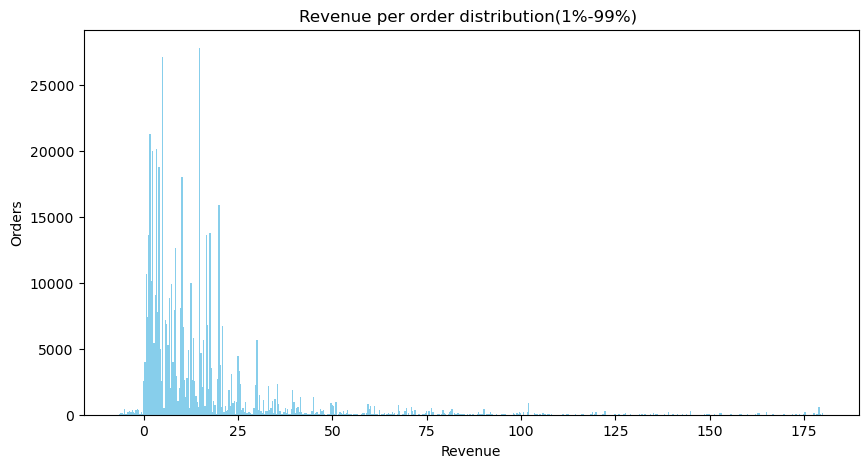

In [44]:
clean_revenue=df[(df["revenue"]>=df["revenue"].quantile(0.01)) & (df["revenue"]<=df["revenue"].quantile(0.99))]["revenue"]
plt.figure(figsize=(10,5))
plt.hist(clean_revenue,bins="auto",color="skyblue")
plt.title("Revenue per order distribution(1%-99%) ")
plt.xlabel("Revenue")
plt.ylabel("Orders")
plt.show()

Most of the orders are of small revenue.
The distribution is positively skewed since the there is a long tail extending to the right side.
The typical customer is a low to medium spender since most orders fall in the lower revenue range.

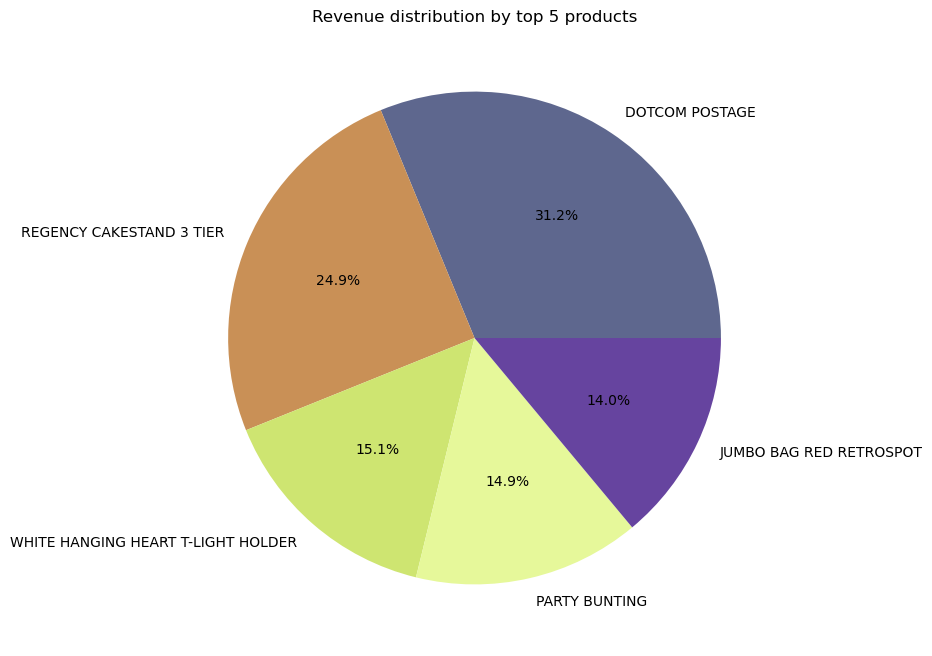

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import random
df=pd.read_csv("Cleaned_ecommerce_data.csv")

description_revenue=df.groupby("description")["revenue"].sum()
top_description=description_revenue.sort_values(ascending=False).head(5)
colors=["#"+"".join(random.choices("0123456789ABCDEF",k=6))
        for i in range(len(top_description))]
plt.figure(figsize=(8,8))
plt.pie(top_description,labels=top_description.index,autopct="%1.1f%%",colors=colors)
plt.title("Revenue distribution by top 5 products")
plt.show()

DOTCOM POSTAGE is the most important product to the business since it has the highest revenue percentage

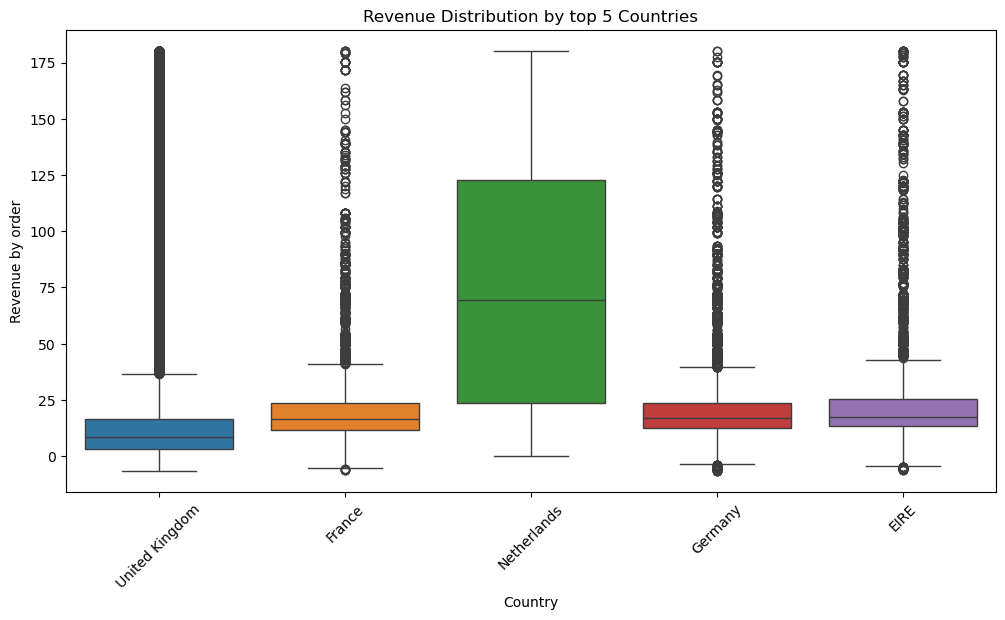

In [20]:
import seaborn as sns
clean_revenue=df[(df["revenue"]>=df["revenue"].quantile(0.01)) & (df["revenue"]<=df["revenue"].quantile(0.99))]
top_countries=clean_revenue.groupby("country")["revenue"].sum().nlargest(5).index
plt.figure(figsize=(12,6))
sns.boxplot(data=clean_revenue[clean_revenue["country"].isin(top_countries)], x="country",y="revenue",hue="country")
plt.title("Revenue Distribution by top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Revenue by order")
plt.xticks(rotation=45)
plt.show()


Choose a boxplot of revenue by country because it helps analyze customer spending patterns.
It shows the distribution of revenue across different countries.It shows the median,outliers and the spread of revenue.

The question I was trying to answer was :"How does the customer spending differ among countries?"

SECTION 5:INSIGHTS

INSIGHT 1:
From the bar chart,it shows the United Kingdom has the highest number of orders suggesting it is the strongest market in the dataset.It also indicates that sales are concentrated most in the country and it has a stronger customer adoption.
From the bar chart, it shows that the order volume varies alot by country since there is a very huge difference in the bar sizes of the 10 countries.The difference between United Kingdom and the second country among the top 10 countries with the highest number of orders which is Germany is very huge.

INSIGHT 2:
From the line chart,it shows revenue reached its highest point in September suggesting improved sales performance or increased customer demand.
The revenue trend shows a general increase over the month of March to September but with a slight drop during July which may indicate temporary drop in purchase,seasonal changes or reduced cutoner activities.This shows there was an improvement in the business sales.

INSIGHT 3:
From the histogram,it shows that most orders fall within the lower range revenue categories, meaning majority of the customers are making moderately sized purchase.
A smaller number of orders have very high revenue values suggesting presence of premium customers of large transactions.
The distribution is right skewed where high value goods increase the overall revenue.

INSIGHT 4:
From the pie chart, it shows Dotcom Postage is the leading product category contributing the largest share.
The top 2 contribute significantly to the business hence the business relies on them heavily among the top 5. Focusing on these high performing products while developing strategies to increase adoption of lower perfoming products could improve overall revenue.

INSIGHT 5:
From the seaborn chart,the analysis show that revenue per order varies across countries.Some countries have consistently higher order value,while others show lower spending.
The outliers suggest the presence of some customers making large orders.This might be very usefull in marketing strategies since information can be obtained from the customers to boost market

SECTION 6:BUSINESS RECOMMENDATIONS

The data suggests that the business should focus more resources on the smaller markets to try and grow them.This is because there is a very big gap on the number of orders between the top country and the rest of the countries.


The business should run its biggest promotions during the month of September since it was the peak of the line chart hence more market.
The business should prepare its stock and staff during the month of January and August before peak sales periods.

For the worst selling products: analyze the reason for low sales,improve market visibility and consider price adjustments

Advice the business to look into the other countries markets; study them and find out important details such as what products are of high demand there, how is there customer services and many others .This will help inrease the orders in the other countries hence increase in the total revenue and reduce the big gap in the number of orders among the top countries as suggested by the bar chart.

Recommendations:

1.Focus and improve performance on the countries with low orders.

2.Focus advertising and promotions on the top countries

3.Analyze customer preference and increase the number of the high demand products in the countries

REFLECTION PARAGRAPH:

The data set revealed that the business might be focusing more on the United Kingdom due to a very high number of orders in the country which takes a higher percentage of the revenue contribution compared to the other countries.

The thing that surprised me most was that the peak month was September.It was unexpected since for businesses most of the peak months are December and January or the beggining of holidays.

It was really hard to make a choice on whether to drop the rows with no CustomerID or to just fill them with unknown since the buyer could not be identified ;but decided to fill with unknown since as much as there is no customerID the transaction can still be identified using the invoice numbers.

If given more time;I would investigate on why there is a very big gap on the number of orders among the top 10 countries and find a way to reduce that gap.